生成内部点数: 1623
生成边界点数: 100
Patch 数量: 22
预测点数: 1623


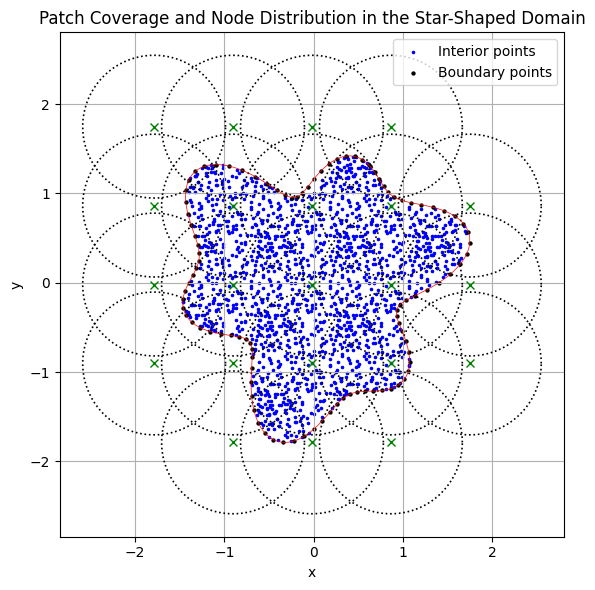

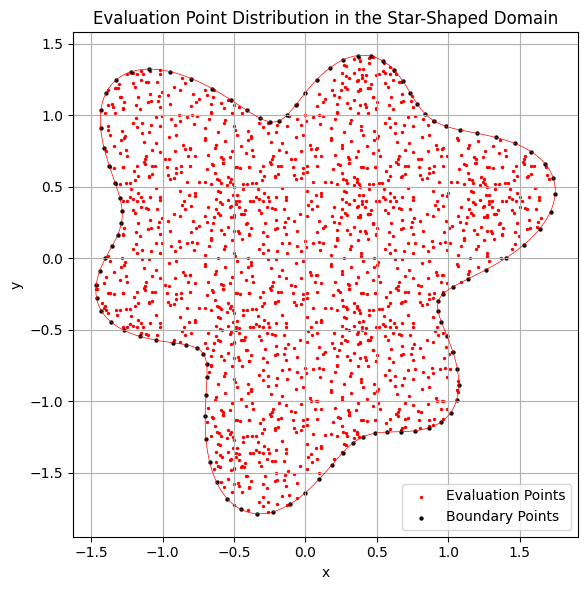

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()

    plt.show()


# ============================
# Example usage
# ============================
if __name__ == "__main__":
    # parameters (same defaults as your MATLAB example)
    N_patch_grid = 5
    N_local_per_patch = 200
    N_boundary = 100
    R_ptch = 0.8
    mode = "c-rbf-pum"  # or "ls-rbf-pum"

    X_inner, X_boundary, ptch, grid_eval, boundary_curve = generator_points_star(
        N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode
    )

    print("生成内部点数:", X_inner.shape[0])
    print("生成边界点数:", X_boundary.shape[0])
    print("Patch 数量:", ptch['C'].shape[0])
    print("预测点数:", grid_eval.shape[0])

    # 绘图
    plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve)

X.shape: (1823, 2)
Time to construct L and LI: 2.7605140209198 seconds
Newton iter 0, relative residual: 3.05e+00
Newton 0: rel_res = 3.050e+00, rel_step = 9.856e-02
Newton iter 1, relative residual: 1.87e-01
Newton 1: rel_res = 1.866e-01, rel_step = 3.051e-02
Newton iter 2, relative residual: 1.94e-02
Newton 2: rel_res = 1.943e-02, rel_step = 5.488e-03
Newton iter 3, relative residual: 7.32e-04
Newton 3: rel_res = 7.317e-04, rel_step = 1.616e-04
Newton iter 4, relative residual: 6.31e-07
Newton 4: rel_res = 6.312e-07, rel_step = 1.281e-07
Newton iter 5, relative residual: 8.24e-13
Newton 5: rel_res = 8.237e-13, rel_step = 1.083e-13
Newton iter 6, relative residual: 6.82e-13
Newton 6: rel_res = 6.823e-13, rel_step = 6.890e-14
L infity error in u: 1.511e-06
Relative L2 error in u: 7.781e-07


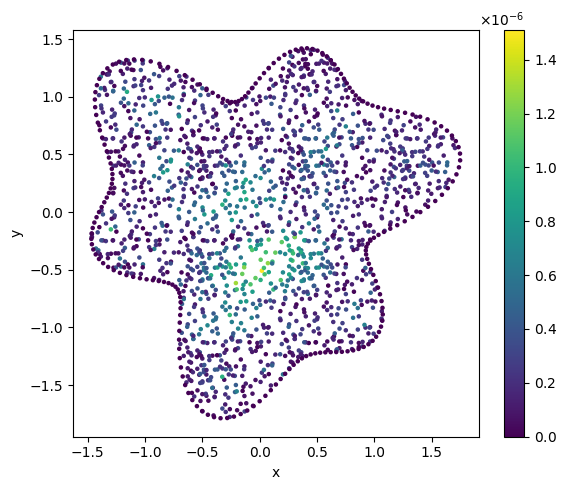

In [2]:
import torch
import time
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.io import loadmat
from scipy.spatial import cKDTree, distance
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, lsqr

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()


def laplacian_phi_wrt_y(phi_net, y, X):
    """
    y: tensor (1,2) evalution points, requires_grad = True
    X: tensor (K,2) source points
    Returns: phi_vals (K,1), laplacian_y (K,1), grad_y (K,2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim()==1:
        y = y.unsqueeze(0)   # (1,2)
    K = X.shape[0]
    # compute r_j
    diff = y - X          # (K,2) if y (1,2)
    r = torch.norm(diff, dim=1, keepdim=True)   # (K,1)
    r = r.clamp(min=1e-14)  # 防止除零

    r.requires_grad_(True)    # 需要对 r 求导
    phi_vals = phi_net(r)     # (K,1)
    # phi_vals = phi_gauss(eps,r) # to check whether the laplace using autograd is correct

    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (K,1)

    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]   # (K,1)

    n = y.shape[1]  # dimension, n = 2 here
    lap_r = d2phi_dr2 + (n-1)/r * dphi_dr   # (K,1),
    # print("relative error between  is",relative_loss(lap_r, laplace_phi_gauss(eps, r)))
    # 一阶向量梯度 wrt y： ∇_y φ = φ'(r) * (y - x)/r
    grad_y = dphi_dr * (diff / r)    # broadcasting (K,2): (grad_y1,grad_y2) 
    phi_vals = phi_vals.detach().cpu().numpy()
    lap_r = lap_r.detach().cpu().numpy()
    grad_y = grad_y.detach().cpu().numpy()
    return phi_vals, lap_r, grad_y

def poly2D(Z, order):
    nj = Z.shape[0]
    Norder = (order+1)*(order+2)//2
    P = np.zeros((nj, Norder))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
            idx += 1
    return P

def laplacian_poly2D(y,order):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]     # (1, 2)
    M = y.shape[0]
    x = y[:, 0]           # (M,)
    z = y[:, 1]           # (M,)
    Norder = (order + 1) * (order + 2) // 2
    lap = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            val = np.zeros(M)
            if i >= 2:
                val += i * (i - 1) * (x ** (i - 2)) * (z ** j)
            if j >= 2:
                val += j * (j - 1) * (x ** i) * (z ** (j - 2))
            lap[idx, :] = val
            idx += 1
    return lap

def gradient_poly2D(y,order):
    """
    计算二维多项式基的梯度
    y: M x 2
    return:
        grad_x: Norder x M
        grad_z: Norder x M
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]  # (1,2)
    M = y.shape[0]
    x = y[:, 0]
    z = y[:, 1]
    Norder = (order + 1) * (order + 2) // 2
    grad_x = np.zeros((Norder, M))
    grad_z = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            # 对 x 求导
            if i == 0:
                grad_x[idx, :] = 0.0
            else:
                grad_x[idx, :] = i * (x ** (i - 1)) * (z ** j)
            # 对 z 求导
            if j == 0:
                grad_z[idx, :] = 0.0
            else:
                grad_z[idx, :] = j * (x ** i) * (z ** (j - 1))
            idx += 1
    return grad_x, grad_z

def rfm_fd_poly_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, order, newton_opt):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M1, N))
    Lx = lil_matrix((M1, N))
    Ly = lil_matrix((M1, N))
    LI = lil_matrix((M, N))
    # Construct RHS

    if callable(f_func):
        f_val = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        f_val = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        g_val = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        g_val = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    start_time = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i:i+1, :]   # (1,2)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, grad_phi  = laplacian_phi_wrt_y(Phi, y, Z) # (K,1), (K,2)
        phi_xj = phi_xj.reshape(K, 1)
        lap_phi = lap_phi.reshape(K, 1)
        grad_phi_y1, grad_phi_y2 = grad_phi[:,0:1], grad_phi[:,1:]

        P = poly2D(Z, order) # (K,Norder)
        AP[:K,:K] = Phi_jj
        AP[:K,K:] = P
        AP[K:,:K] = P.T
        AP = AP + reg * np.eye(K+Norder) # regularization

        poly_y = poly2D(y, order) # (1,Norder)
        lap_poly_y = laplacian_poly2D(y, order) # (Norder,1)
        grad_poly_y1, grad_poly_y2 = gradient_poly2D(y, order) # (Norder,1)

        RHS_ide = np.concatenate([phi_xj, poly_y.T], axis=0) # (K+Norder,1)
        RHS_gradx = np.concatenate([grad_phi_y1, grad_poly_y1], axis=0) # (K+Norder,1)
        RHS_grady = np.concatenate([grad_phi_y2, grad_poly_y2], axis=0) # (K+Norder,1)
        RHS_lap = np.concatenate([lap_phi, lap_poly_y], axis=0) # (K+Norder,1)
        RHS_all = np.concatenate([RHS_lap,RHS_gradx,RHS_grady,RHS_ide], axis=1) # (K+Norder,4)
        w_all = np.linalg.solve(AP,RHS_all).T # (4,K+Noder)
        w_lap = w_all[0,:K] # (K,)
        w_gradx = w_all[1,:K] # (K,)
        w_grady = w_all[2,:K] # (K,)
        w_ide = w_all[3,:K] # (K,)
        if i < M1:
            L[i, idx_local] = L[i, idx_local] + w_lap  
            Lx[i, idx_local] = Lx[i, idx_local] + w_gradx
            Ly[i, idx_local] = Ly[i, idx_local] + w_grady
        LI[i,idx_local] = LI[i,idx_local] + w_ide

    # ===========================================================
    # Solve nonlinear system 
    # div((1+u^2) grad u) = 10f
    # ===========================================================
    end_time = time.time()
    print("Time to construct L and LI:", end_time - start_time, "seconds")
    L = L.tocsr()
    Lx = Lx.tocsr()
    Ly = Ly.tocsr()
    LI = LI.tocsr()
    RHS = np.concatenate([10*f_val,g_val],axis=0)
    L1 = scipy.sparse.vstack([L,LI[M1:,:]])
    if M == N:
        alpha = spsolve(L1,RHS)
    else:
        alpha = lsqr(L1, RHS,
            atol= 1e-12,
            btol= 1e-12,
            iter_lim= 2000)[0]

    info = {
        "newton_iters": 0,
        "newton_res": [],
        "newton_step": [],
    }
    rhs_norm = np.linalg.norm(np.concatenate([10 * f_val, g_val])) + 1e-14
    alpha = np.asarray(alpha).reshape(-1)
    for iter in range(newton_opt["maxiter"]):
        UY_int = LI[:M1,:] @ alpha  # (M1,)
        UY_dx = Lx @ alpha
        UY_dy = Ly @ alpha
        UY_lap = L @ alpha
        F_int = ((1.0 + UY_int**2) * UY_lap + 2.0 * UY_int * (UY_dx**2 + UY_dy**2) - 10.0 * f_val.flatten()) #(M1,)
        F_bnd = LI[M1:,:] @ alpha - g_val.flatten()  # (M2,)
        F = np.concatenate([F_int, F_bnd], axis=0)  # (M,1)
        res_norm = np.linalg.norm(F) / rhs_norm
        info["newton_res"].append(res_norm)
        print(f"Newton iter {iter}, relative residual: {res_norm:.2e}")
        # Jacobian: only interior part
        J_int = (scipy.sparse.diags(1.0 + UY_int**2) @ L+ scipy.sparse.diags(2.0 * UY_int * UY_lap) @ LI[:M1,:]+ scipy.sparse.diags(2.0 * (UY_dx**2 + UY_dy**2)) @ LI[:M1,:]+ scipy.sparse.diags(4.0 * UY_int * UY_dx) @ Lx+ scipy.sparse.diags(4.0 * UY_int * UY_dy) @ Ly)
        J_bnd = LI[M1:,:]
        J = scipy.sparse.vstack([J_int, J_bnd])  # (M,N)

        row_max = abs(J).max(axis=1).toarray().ravel()
        row_max[row_max < 1e-14] = 1.0
        scale = 1.0 / row_max
        D = scipy.sparse.diags(scale)
        J_scaled = D @ J
        F_scaled = scale * F
        if J_scaled.shape[0] == J_scaled.shape[1]:
            delta = spsolve(J_scaled, -F_scaled)
        else:
            delta = lsqr(
                J_scaled,
                -F_scaled,
                atol=1e-12,
                btol=1e-12,
                iter_lim=2000)[0]   
        alpha +=   newton_opt["damping"] * delta
        step_norm = np.linalg.norm(delta)/ (np.linalg.norm(alpha) + 1e-14)

        info["newton_res"].append(res_norm)
        info["newton_step"].append(step_norm)
        print(f"Newton {iter}: rel_res = {res_norm:.3e}, rel_step = {step_norm:.3e}")
        if res_norm < newton_opt["tol"] or step_norm < newton_opt["tol"]:
            break
    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    info["newton_iters"] = iter
    info["newton_res"] = np.array(info["newton_res"])
    info["newton_step"] = np.array(info["newton_step"])

    UY = LI.dot(alpha).reshape(-1,1)
    UY[M1:,:] = g_val
    return UY,L,Lx,Ly,LI

def rfm_fd_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, newton_opt):
    """
    X:  (N,2)   source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M1, N))
    Lx = lil_matrix((M1, N))
    Ly = lil_matrix((M1, N))
    LI = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        f_val = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        f_val = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        g_val = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        g_val = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    start_time = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))

        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)

        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, grad_phi  = laplacian_phi_wrt_y(Phi, y, Z) # (K,1)
        grad_phi_y1, grad_phi_y2 = grad_phi[:,0:1], grad_phi[:,1:]

        AP = Phi_jj
        AP = AP + reg * np.eye(K) # regularization
        
        RHS_ide = phi_xj # (K,1)
        RHS_gradx = grad_phi_y1
        RHS_grady = grad_phi_y2
        RHS_lap = lap_phi # (K,1)
        RHS_all = np.concatenate([RHS_lap,RHS_gradx,RHS_grady,RHS_ide], axis=1) # (K,4)
        w_all = np.linalg.solve(AP,RHS_all).T # (4,K)
        w_lap = w_all[0,:] # (K,)
        w_gradx = w_all[1,:] # (K,)
        w_grady = w_all[2,:] # (K,)
        w_ide = w_all[3,:] # (K,)
        if i < M1:
            L[i, idx_local] = L[i, idx_local]  + w_lap
            Lx[i, idx_local] = Lx[i, idx_local]  + w_gradx
            Ly[i, idx_local] = Ly[i, idx_local]  + w_grady
        LI[i,idx_local] = LI[i,idx_local] + w_ide

    # ===========================================================
    # Solve nonlinear system 
    #   in Omega, u = g on boundary
    # ===========================================================
    end_time = time.time()
    print("Time to construct L and LI:", end_time - start_time, "seconds")
    L = L.tocsr()
    Lx = Lx.tocsr()
    Ly = Ly.tocsr()
    LI = LI.tocsr()
    # take linear poisson solution as inital guess.
    RHS = np.concatenate([10*f_val,g_val],axis=0)
    L1 = scipy.sparse.vstack([L,LI[M1:,:]])
    if M == N:
        alpha = spsolve(L1,RHS)
    else:
        alpha = lsqr(L1, RHS,
            atol= 1e-12,
            btol= 1e-12,
            iter_lim= 2000)[0]
    
    info = {
        "newton_iters": 0,
        "newton_res": [],
        "newton_step": [],
    }
    rhs_norm = np.linalg.norm(np.concatenate([10 * f_val, g_val])) + 1e-14
    alpha = np.asarray(alpha).reshape(-1)
    for iter in range(newton_opt["maxiter"]):
        UY_int = LI[:M1,:] @ alpha  # (M1,)
        UY_dx = Lx @ alpha
        UY_dy = Ly @ alpha
        UY_lap = L @ alpha
        
        F_int = ((1.0 + UY_int**2) * UY_lap + 2.0 * UY_int * (UY_dx**2 + UY_dy**2) - 10.0 * f_val.flatten()) #(M1,)
        F_bnd = LI[M1:,:] @ alpha - g_val.flatten()  # (M2,)
        F = np.concatenate([F_int, F_bnd], axis=0)  # (M,1)
        res_norm = np.linalg.norm(F) #/ rhs_norm
        info["newton_res"].append(res_norm)
        print(f"Newton iter {iter}, relative residual: {res_norm:.2e}")
        # Jacobian: only interior part
        J_int = (scipy.sparse.diags(1.0 + UY_int**2) @ L+ scipy.sparse.diags(2.0 * UY_int * UY_lap) @ LI[:M1,:]+ scipy.sparse.diags(2.0 * (UY_dx**2 + UY_dy**2)) @ LI[:M1,:]+ scipy.sparse.diags(4.0 * UY_int * UY_dx) @ Lx+ scipy.sparse.diags(4.0 * UY_int * UY_dy) @ Ly)
        J_bnd = LI[M1:,:]
        J = scipy.sparse.vstack([J_int, J_bnd])  # (M,N)
        if M == N:
            delta = spsolve(J, -F)  # (M,)
        else:
            delta = lsqr(J, -F)[0]  # (M,)
        alpha +=   newton_opt["damping"] * delta
        step_norm = np.linalg.norm(delta)/ (np.linalg.norm(alpha) + 1e-14)

        info["newton_res"].append(res_norm)
        info["newton_step"].append(step_norm)
        print(f"Newton {iter}: rel_res = {res_norm:.3e}, rel_step = {step_norm:.3e}")
        if res_norm < newton_opt["tol"] or step_norm < newton_opt["tol"]:
            break
    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    info["newton_iters"] = iter
    info["newton_res"] = np.array(info["newton_res"])
    info["newton_step"] = np.array(info["newton_step"])

    UY = LI.dot(alpha).reshape(-1,1)
    UY[M1:,:] = g_val
    return UY,LI,Lx,Ly,L


def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = None) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    m.bias.data.zero_()
                    # nn.init.uniform_(m.bias,-torch.pi,torch.pi)

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 10
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# div((1+u^2) grad u) = 10f

u_func = lambda x, y: x * np.sin(y)
f_func = lambda x, y: (1.0/10.0) * x * np.sin(y) * (-1.0 + 2.0*np.sin(y)**2 + x**2 * (2.0*np.cos(y)**2 - np.sin(y)**2))
g_func = lambda x, y: u_func(x,y)

torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])
print("X.shape:", X.shape)
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
K = 100
reg = 1e-14
order = 3
u_true = u_func(Y[:,0:1], Y[:,1:2])

newton_opt={"maxiter": 20, "tol": 1e-13, "damping": 1.0}
# # ===========================================================
if order == 0:
    UY,LI,Lx,Ly,L = rfm_fd_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, newton_opt)
else:
    UY,LI,Lx,Ly,L = rfm_fd_poly_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, order, newton_opt)

# print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
# print(error)
# if global_error_vmax <= error.max().item():
#     global_error_vmax = error.max().item()
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5,)
# sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5, vmin=global_error_vmin,
#     vmax=global_error_vmax)
cbar = plt.colorbar(sc)
# cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'./result/nonlinear_poisson_rfmfd_p={order}_error_sincos.eps', bbox_inches='tight')
plt.show()

##

# Operator Learning

In [3]:
from scipy.sparse import vstack, eye
from scipy.sparse.linalg import lsqr

def rfm_fd_poly_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, order, newton_opt):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M1, N))
    Lx = lil_matrix((M1, N))
    Ly = lil_matrix((M1, N))
    LI = lil_matrix((M, N))
    # Construct RHS

    if callable(f_func):
        f_val = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        f_val = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        g_val = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        g_val = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    print(f_val.shape, g_val.shape)

    start_time = time.time()
    t_deriv = 0.0
    t_solve = 0.0
    t_sparse = 0.0
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i:i+1, :]   # (1,2)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        t0 = time.time()
        phi_xj, lap_phi, grad_phi  = laplacian_phi_wrt_y(Phi, y, Z) # (K,1), (K,2)
        phi_xj = phi_xj.reshape(K, 1)
        lap_phi = lap_phi.reshape(K, 1)
        grad_phi_y1, grad_phi_y2 = grad_phi[:,0:1], grad_phi[:,1:]
        t_deriv += time.time() - t0

        P = poly2D(Z, order) # (K,Norder)
        AP[:K,:K] = Phi_jj
        AP[:K,K:] = P
        AP[K:,:K] = P.T
        AP = AP + reg * np.eye(K+Norder) # regularization

        poly_y = poly2D(y, order) # (1,Norder)
        lap_poly_y = laplacian_poly2D(y, order) # (Norder,1)
        grad_poly_y1, grad_poly_y2 = gradient_poly2D(y, order) # (Norder,1)

        RHS_ide = np.concatenate([phi_xj, poly_y.T], axis=0) # (K+Norder,1)
        RHS_gradx = np.concatenate([grad_phi_y1, grad_poly_y1], axis=0) # (K+Norder,1)
        RHS_grady = np.concatenate([grad_phi_y2, grad_poly_y2], axis=0) # (K+Norder,1)
        RHS_lap = np.concatenate([lap_phi, lap_poly_y], axis=0) # (K+Norder,1)
        RHS_all = np.concatenate([RHS_lap,RHS_gradx,RHS_grady,RHS_ide], axis=1) # (K+Norder,4)
        
        t0 = time.time()
        w_all = np.linalg.solve(AP,RHS_all).T # (4,K+Noder)
        t_solve += time.time() - t0

        w_lap = w_all[0,:K] # (K,)
        w_gradx = w_all[1,:K] # (K,)
        w_grady = w_all[2,:K] # (K,)
        w_ide = w_all[3,:K] # (K,)
        t0 = time.time()
        if i < M1:
            L[i, idx_local] = L[i, idx_local] + w_lap  
            Lx[i, idx_local] = Lx[i, idx_local] + w_gradx
            Ly[i, idx_local] = Ly[i, idx_local] + w_grady
        LI[i,idx_local] = LI[i,idx_local] + w_ide
        t_sparse += time.time() - t0
    # ===========================================================
    # Solve nonlinear system 
    # div((1+u^2) grad u) = 10f
    # ===========================================================
    end_time = time.time()
    print("Time to construct L and LI:", end_time - start_time, "seconds")
    print("========== FD timing report ==========")
    print("derivatives   =", t_deriv)
    print("local solve   =", t_solve)
    print("sparse write  =", t_sparse)
    
    
    L = L.tocsr()
    Lx = Lx.tocsr()
    Ly = Ly.tocsr()
    LI = LI.tocsr()
    
    RHS = np.concatenate([10*f_val.flatten(), g_val.flatten()])
    L1 = scipy.sparse.vstack([L, LI[M1:,:]]).tocsr()
    if L1.shape[0] == L1.shape[1]:
        alpha = spsolve(L1,RHS)
    else:
        alpha = lsqr(L1, RHS, atol=newton_opt["damping"], btol=newton_opt["damping"], iter_lim=2000)[0]

    info = {
        "newton_iters": 0,
        "newton_res": [],
        "newton_step": [],
    }
    rhs_norm = np.linalg.norm(np.concatenate([10 * f_val, g_val])) + 1e-14
    alpha = np.asarray(alpha).reshape(-1)
    for iter in range(newton_opt["maxiter"]):
        UY_int = LI[:M1,:] @ alpha  # (M1,)
        UY_dx = Lx @ alpha
        UY_dy = Ly @ alpha
        UY_lap = L @ alpha
        F_int = ((1.0 + UY_int**2) * UY_lap + 2.0 * UY_int * (UY_dx**2 + UY_dy**2) - 10.0 * f_val.flatten()) #(M1,)
        F_bnd = LI[M1:,:] @ alpha - g_val.flatten()  # (M2,)
        F = np.concatenate([F_int, F_bnd], axis=0)  # (M,1)
        res_norm = np.linalg.norm(F) / rhs_norm
        info["newton_res"].append(res_norm)
        print(f"Newton iter {iter}, relative residual: {res_norm:.2e}")
        # Jacobian: only interior part
        J_int = (scipy.sparse.diags(1.0 + UY_int**2) @ L+ scipy.sparse.diags(2.0 * UY_int * UY_lap) @ LI[:M1,:]+ scipy.sparse.diags(2.0 * (UY_dx**2 + UY_dy**2)) @ LI[:M1,:]+ scipy.sparse.diags(4.0 * UY_int * UY_dx) @ Lx+ scipy.sparse.diags(4.0 * UY_int * UY_dy) @ Ly)
        J_bnd = LI[M1:,:]
        J = scipy.sparse.vstack([J_int, J_bnd])  # (M,N)

        row_max = abs(J).max(axis=1).toarray().ravel()
        row_max[row_max < 1e-14] = 1.0
        scale = 1 / row_max
        D = scipy.sparse.diags(scale)
        J_scaled = D @ J
        F_scaled = scale * F
        if J_scaled.shape[0] == J_scaled.shape[1]:
            delta = spsolve(J_scaled, -F_scaled)
        else:
            delta = lsqr(J_scaled,
                         -F_scaled,
                         atol=newton_opt["damping"],
                         btol=newton_opt["damping"],
                         iter_lim=2000)[0]

        alpha +=   newton_opt["linearstep"] * delta
        step_norm = np.linalg.norm(delta)/ (np.linalg.norm(alpha) + 1e-14)

        info["newton_res"].append(res_norm)
        info["newton_step"].append(step_norm)
        print(f"Newton {iter}: rel_res = {res_norm:.3e}, rel_step = {step_norm:.3e}")
        if res_norm < newton_opt["tol"]:
            break
        if step_norm < newton_opt["tol"]:
            print("Warning: step is small but residual is not small.")
            break
        
    lin_res = np.linalg.norm(J_scaled @ delta + F_scaled) / (np.linalg.norm(F_scaled) + 1e-14)
    print("linear solve residual:", lin_res)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    info["newton_iters"] = iter
    info["newton_res"] = np.array(info["newton_res"])
    info["newton_step"] = np.array(info["newton_step"])

    UY = LI.dot(alpha).reshape(-1,1)
    UY[M1:,:] = g_val
    return UY,LI,Lx,Ly,L

def rfm_fd_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, newton_opt):
    """
    X:  (N,2)   source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M1, N))
    Lx = lil_matrix((M1, N))
    Ly = lil_matrix((M1, N))
    LI = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        f_val = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        f_val = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        g_val = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        g_val = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    start_time = time.time()
    t_deriv = 0.0
    t_solve = 0.0
    t_sparse = 0.0
    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))

        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)

        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        t0 = time.time()
        phi_xj, lap_phi, grad_phi  = laplacian_phi_wrt_y(Phi, y, Z) # (K,1)
        grad_phi_y1, grad_phi_y2 = grad_phi[:,0:1], grad_phi[:,1:]
        t_deriv += time.time() - t0

        AP = Phi_jj
        AP = AP + reg * np.eye(K) # regularization
        
        RHS_ide = phi_xj # (K,1)
        RHS_gradx = grad_phi_y1
        RHS_grady = grad_phi_y2
        RHS_lap = lap_phi # (K,1)
        RHS_all = np.concatenate([RHS_lap,RHS_gradx,RHS_grady,RHS_ide], axis=1) # (K,4)
        t0 = time.time()
        w_all = np.linalg.solve(AP,RHS_all).T # (4,K)
        t_solve += time.time() - t0

        w_lap = w_all[0,:] # (K,)
        w_gradx = w_all[1,:] # (K,)
        w_grady = w_all[2,:] # (K,)
        w_ide = w_all[3,:] # (K,)
        t0 = time.time()
        if i < M1:
            L[i, idx_local] = L[i, idx_local]  + w_lap
            Lx[i, idx_local] = Lx[i, idx_local]  + w_gradx
            Ly[i, idx_local] = Ly[i, idx_local]  + w_grady
        LI[i,idx_local] = LI[i,idx_local] + w_ide
        t_sparse += time.time() - t0
    # ===========================================================
    # Solve nonlinear system 
    #   in Omega, u = g on boundary
    # ===========================================================
    end_time = time.time()
    print("Time to construct L and LI:", end_time - start_time, "seconds")
    print("========== FD timing report ==========")
    print("derivatives   =", t_deriv)
    print("local solve   =", t_solve)
    print("sparse write  =", t_sparse)
    
    
    
    L = L.tocsr()
    Lx = Lx.tocsr()
    Ly = Ly.tocsr()
    LI = LI.tocsr()

    ###take linear poisson solution as inital guess.
    RHS = np.concatenate([10*f_val,g_val],axis=0)
    L1 = scipy.sparse.vstack([L,LI[M1:,:]])
    if M == N:
        alpha = spsolve(L1,RHS)
    else:
        alpha = lsqr(L1, RHS,
            atol= newton_opt["damping"],
            btol= newton_opt["damping"],
            iter_lim= 3000)[0]
    #test
    # U_guess= np.zeros(M,1)
    # U_guess[M1:,:] = g_val
    # alpha = lsqr(LI, U_guess,
    #         atol= 1e-12,
    #         btol= 1e-12,
    #         iter_lim= 1000)[0]

    info = {
        "newton_iters": 0,
        "newton_res": [],
        "newton_step": [],
    }
    rhs_norm = np.linalg.norm(np.concatenate([10 * f_val, g_val])) + 1e-14
    alpha = np.asarray(alpha).reshape(-1)
    for iter in range(newton_opt["maxiter"]):
        UY_int = LI[:M1,:] @ alpha  # (M1,)
        UY_dx = Lx @ alpha
        UY_dy = Ly @ alpha
        UY_lap = L @ alpha
        
        F_int = ((1.0 + UY_int**2) * UY_lap + 2.0 * UY_int * (UY_dx**2 + UY_dy**2) - 10.0 * f_val.flatten()) #(M1,)
        F_bnd = LI[M1:,:] @ alpha - g_val.flatten()  # (M2,)
        F = np.concatenate([F_int, F_bnd], axis=0)  # (M,1)
        res_norm = np.linalg.norm(F) / rhs_norm
        info["newton_res"].append(res_norm)
        print(f"Newton iter {iter}, relative residual: {res_norm:.2e}")
        # Jacobian: only interior part
        J_int = (scipy.sparse.diags(1.0 + UY_int**2) @ L+ scipy.sparse.diags(2.0 * UY_int * UY_lap) @ LI[:M1,:]+ scipy.sparse.diags(2.0 * (UY_dx**2 + UY_dy**2)) @ LI[:M1,:]+ scipy.sparse.diags(4.0 * UY_int * UY_dx) @ Lx+ scipy.sparse.diags(4.0 * UY_int * UY_dy) @ Ly)
        J_bnd = LI[M1:,:]
        J = scipy.sparse.vstack([J_int, J_bnd])  # (M,N)
        if M == N:
            delta = spsolve(J, -F)  # (M,)
        else:
            delta = lsqr(J, -F,atol=newton_opt["damping"],
                         btol=newton_opt["damping"],
                         iter_lim=3000)[0]  # (M,)
        alpha +=   newton_opt["linearstep"] * delta
        step_norm = np.linalg.norm(delta)/ (np.linalg.norm(alpha) + 1e-14)

        info["newton_res"].append(res_norm)
        info["newton_step"].append(step_norm)
        print(f"Newton {iter}: rel_res = {res_norm:.3e}, rel_step = {step_norm:.3e}")
        if res_norm < newton_opt["tol"] or step_norm < newton_opt["tol"]:
            break
    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    info["newton_iters"] = iter
    info["newton_res"] = np.array(info["newton_res"])
    info["newton_step"] = np.array(info["newton_step"])

    UY = LI.dot(alpha).reshape(-1,1)
    UY[M1:,:] = g_val
    return UY,LI,Lx,Ly,L



X_inner.shape: 408, X_boundary.shape:50
(617, 1) (80, 1)
Time to construct L and LI: 0.8454251289367676 seconds
========== FD timing report ==========
derivatives   = 0.3011496067047119
local solve   = 0.027173995971679688
sparse write  = 0.3080761432647705
Newton iter 0, relative residual: 9.46e-01
Newton 0: rel_res = 9.458e-01, rel_step = 2.678e-01
Newton iter 1, relative residual: 1.12e-01
Newton 1: rel_res = 1.118e-01, rel_step = 1.073e-01
Newton iter 2, relative residual: 8.73e-03
Newton 2: rel_res = 8.731e-03, rel_step = 1.052e-01
Newton iter 3, relative residual: 8.16e-03
Newton 3: rel_res = 8.163e-03, rel_step = 4.051e-02
Newton iter 4, relative residual: 7.97e-03
Newton 4: rel_res = 7.967e-03, rel_step = 3.638e-02
Newton iter 5, relative residual: 7.77e-03
Newton 5: rel_res = 7.769e-03, rel_step = 2.887e-02
Newton iter 6, relative residual: 7.69e-03
Newton 6: rel_res = 7.695e-03, rel_step = 2.658e-02
Newton iter 7, relative residual: 7.56e-03
Newton 7: rel_res = 7.560e-03, rel

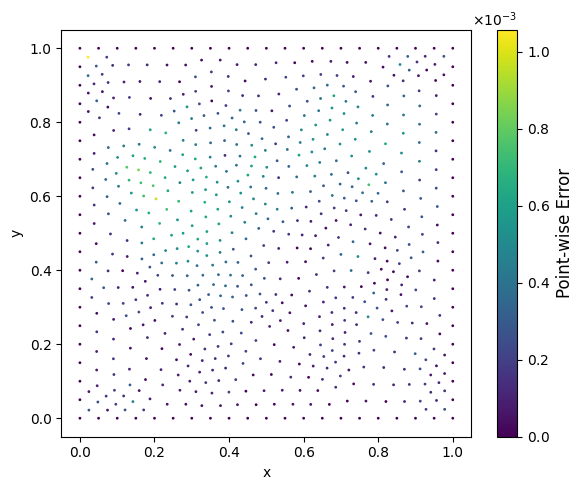

In [4]:

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 20
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y: x * np.cos(y)
# f_func = lambda x, y: 0 * np.cos(y) + x * np.cos(y)
# g_func = lambda x, y: x * np.cos(y)
# #===========================================================
# #==================== Evaluate points Y ====================
# #===========================================================
data = loadmat('./data/mydata_100_pdetool_square_697.mat') # sigma2 = 0.1, l = 0.25

p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
Y = np.concatenate([Yin,Yb],axis=0)
f_func = f_new[index_in,testnum] 
g_func = u_new[index_bc,testnum]
order = 3
K = 50
reg = 1e-14
u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================

N_patch_grid = 5
N_local_per_patch = 50
N_boundary = 50
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
print(f"X_inner.shape: {X_inner.shape[0]}, X_boundary.shape:{X_boundary.shape[0]}")
X = np.vstack([X_inner, X_boundary])

# print(f"X.shape, {X.shape}")
# # ===========================================================
newton_opt={"maxiter": 20, "tol": 1e-13, "damping": 1e-12, "linearstep": 1}

if order == 0:
    UY,LI,Lx,Ly,L = rfm_fd_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, newton_opt)
else:
    UY,LI,Lx,Ly,L = rfm_fd_poly_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, order, newton_opt)

print("p = ", order, "u_true.shape: ",u_true.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
print(error.max().item())
print(error[M1:,:].max().item())

print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=1)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_xcos_operator.eps', bbox_inches='tight')
plt.show()

## |Y| \noneq |X|, k = 150
## order = 0, reg = 1e-
## order = 1, reg = 1e-
## order = 2, reg = 1e-14 (1.812%) > 1e-13(2.04%) > 1e-12(2.45%) >1e-15 
## order = 3, reg = 1e-14 > 1e-13 > 1e-12 > 1e-15(>:better)


In [5]:
def test_solver_batch(L, Lx, Ly, LI, f_vec, g_vec, newton_opt):
    M1 = f_vec.shape[0]
    M2 = g_vec.shape[0]
    M = M1 + M2
    N = LI.shape[1]
    ns = f_vec.shape[1]

    f_vec = np.asarray(f_vec, dtype=np.float64)
    g_vec = np.asarray(g_vec, dtype=np.float64)

    L1 = scipy.sparse.vstack([L, LI[M1:, :]]).tocsr()
    RHS_all = np.vstack([10.0 * f_vec, g_vec])

    # Linear Poisson initial guess
    if L1.shape[0] == L1.shape[1]:
        Alpha = spsolve(L1, RHS_all)
        Alpha = np.asarray(Alpha)
        if Alpha.ndim == 1:
            Alpha = Alpha[:, None]
    else:
        Alpha = np.column_stack([
            lsqr(L1, RHS_all[:, s], atol=1e-12, btol=1e-12, iter_lim=1000)[0]
            for s in range(ns)
        ])

    E_int = LI[:M1, :]
    E_bnd = LI[M1:, :]

    info = {
        "newton_res": np.zeros((newton_opt["maxiter"], ns)),
        "newton_step": np.zeros((newton_opt["maxiter"], ns)),
    }

    for it in range(newton_opt["maxiter"]):
        for s in range(ns):
            alpha = Alpha[:, s]
            f_val = f_vec[:, s]
            g_val = g_vec[:, s]

            U = E_int @ alpha
            Ux = Lx @ alpha
            Uy = Ly @ alpha
            LapU = L @ alpha

            F_int = (
                (1.0 + U**2) * LapU
                + 2.0 * U * (Ux**2 + Uy**2)
                - 10.0 * f_val
            )
            F_bnd = E_bnd @ alpha - g_val
            F = np.concatenate([F_int, F_bnd])

            rhs_norm = np.linalg.norm(np.concatenate([10.0 * f_val, g_val])) + 1e-14
            res_norm = np.linalg.norm(F) / rhs_norm

            J_int = (
                scipy.sparse.diags(1.0 + U**2) @ L
                + scipy.sparse.diags(2.0 * U * LapU) @ E_int
                + scipy.sparse.diags(2.0 * (Ux**2 + Uy**2)) @ E_int
                + scipy.sparse.diags(4.0 * U * Ux) @ Lx
                + scipy.sparse.diags(4.0 * U * Uy) @ Ly
            )

            J = scipy.sparse.vstack([J_int, E_bnd]).tocsr()

            row_max = abs(J).max(axis=1).toarray().ravel()
            row_max[row_max < 1e-14] = 1.0
            scale = 1.0 / row_max

            J_scaled = scipy.sparse.diags(scale) @ J
            F_scaled = scale * F

            if J_scaled.shape[0] == J_scaled.shape[1]:
                delta = spsolve(J_scaled, -F_scaled)
            else:
                delta = lsqr(
                    J_scaled,
                    -F_scaled,
                    atol=newton_opt["damping"],
                    btol=newton_opt["damping"],
                    iter_lim=2000
                )[0]

            damping = newton_opt.get("linearstep", 1.0)
            alpha_new = alpha + damping * delta

            step_norm = np.linalg.norm(delta) / (np.linalg.norm(alpha_new) + 1e-14)

            Alpha[:, s] = alpha_new
            info["newton_res"][it, s] = res_norm
            info["newton_step"][it, s] = step_norm

        print(
            f"Newton {it}: "
            f"max rel_res={info['newton_res'][it].max():.3e}, "
            f"mean rel_res={info['newton_res'][it].mean():.3e}"
        )

    UY = LI @ Alpha
    UY[M1:, :] = g_vec

    return UY

In [6]:
import time
# only calculate 20
E_inf, E_L2 = np.zeros((20,1)),np.zeros((20,1))
f_vec = f_new[index_in,:]
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:20],u_true[index_bc,:20]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)


start_time = time.time()
UY = test_solver_batch(L, Lx, Ly, LI, f_vec, g_vec, newton_opt)
UY[M1:,:] = g_vec
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)


(697, 20) (617, 20) (80, 20)
Newton 0: max rel_res=1.417e+00, mean rel_res=1.196e+00
Newton 1: max rel_res=5.212e-01, mean rel_res=4.020e-01
Newton 2: max rel_res=2.447e-02, mean rel_res=1.574e-02
Newton 3: max rel_res=2.390e-02, mean rel_res=1.481e-02
Newton 4: max rel_res=2.356e-02, mean rel_res=1.484e-02
Newton 5: max rel_res=2.388e-02, mean rel_res=1.465e-02
Newton 6: max rel_res=2.406e-02, mean rel_res=1.468e-02
Newton 7: max rel_res=2.403e-02, mean rel_res=1.462e-02
Newton 8: max rel_res=2.413e-02, mean rel_res=1.465e-02
Newton 9: max rel_res=2.417e-02, mean rel_res=1.462e-02
Newton 10: max rel_res=2.420e-02, mean rel_res=1.465e-02
Newton 11: max rel_res=2.424e-02, mean rel_res=1.464e-02
Newton 12: max rel_res=2.425e-02, mean rel_res=1.466e-02
Newton 13: max rel_res=2.430e-02, mean rel_res=1.466e-02
Newton 14: max rel_res=2.431e-02, mean rel_res=1.467e-02
Newton 15: max rel_res=2.436e-02, mean rel_res=1.468e-02
Newton 16: max rel_res=2.437e-02, mean rel_res=1.469e-02
Newton 17: m

q is  3


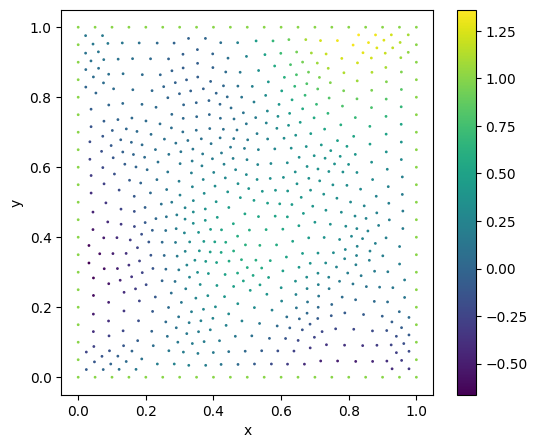

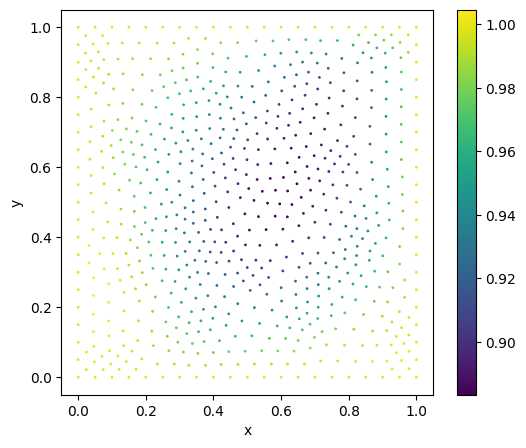

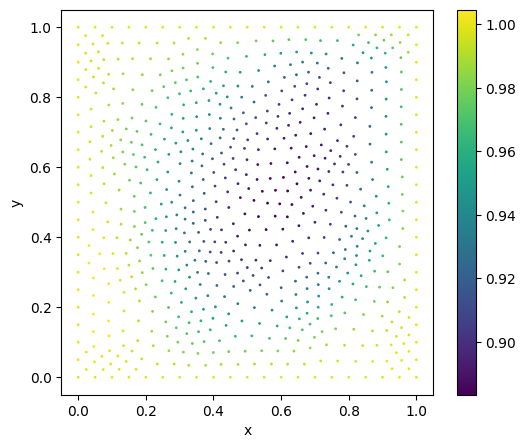

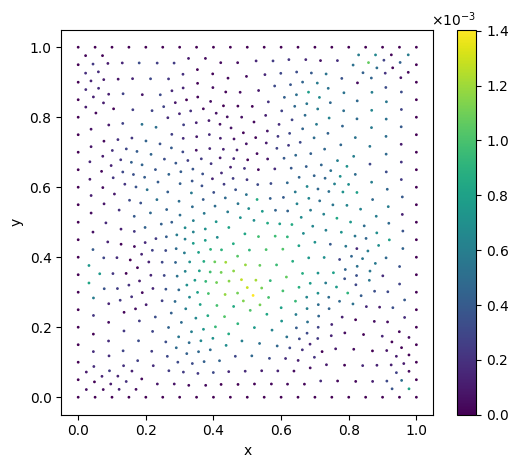

p = 3, test on 20 samples. The mean of max error: 1.299719e-03, and mean of relative L2 error: 3.661824e-04
p = 3, test on 20 samples. The variance of max error: 1.327423e-07, and variance of relative L2 error: 1.182482e-08


In [7]:
np.random.seed(20)
q = np.random.randint(0,20)
print("q is ", q)
f_test = np.concatenate([f_vec[:,q],g_vec[:,q]],axis = 0)
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = f_test, cmap='viridis', s=1)
plt.colorbar(sc)
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/nonlinear_poisson_square_rfmfd_p={order}_f_test_size{M}.eps', bbox_inches='tight')
plt.show()

import matplotlib.colors as mcolors
v_min = u_true[:, q].min()
v_max = u_true[:, q].max()
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=1, norm=norm)
plt.colorbar(sc)
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/nonlinear_poisson_square_rfmfd_p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=1, norm=norm)
plt.colorbar(sc)
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/nonlinear_poisson_square_rfmfd_p={order}_u_rfmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=1)
cbar = plt.colorbar(sc)
# cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/nonlinear_poisson_square_rfmfd_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 20 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 20 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

# uniform 101 * 101

X_inner.shape: 1623, X_boundary.shape:400
(9801, 1) (400, 1)
Time to construct L and LI: 14.776846408843994 seconds
========== FD timing report ==========
derivatives   = 4.520848512649536
local solve   = 0.8500120639801025
sparse write  = 5.0445287227630615
Newton iter 0, relative residual: 3.37e+00
Newton 0: rel_res = 3.373e+00, rel_step = 3.184e-01
Newton iter 1, relative residual: 2.16e+00
Newton 1: rel_res = 2.162e+00, rel_step = 1.182e-01
Newton iter 2, relative residual: 7.22e-02
Newton 2: rel_res = 7.216e-02, rel_step = 8.170e-02
Newton iter 3, relative residual: 2.45e-02
Newton 3: rel_res = 2.455e-02, rel_step = 6.089e-02
Newton iter 4, relative residual: 2.30e-02
Newton 4: rel_res = 2.301e-02, rel_step = 4.163e-02
Newton iter 5, relative residual: 1.92e-02
Newton 5: rel_res = 1.924e-02, rel_step = 4.019e-02
Newton iter 6, relative residual: 1.89e-02
Newton 6: rel_res = 1.886e-02, rel_step = 2.990e-02
Newton iter 7, relative residual: 1.58e-02
Newton 7: rel_res = 1.583e-02, re

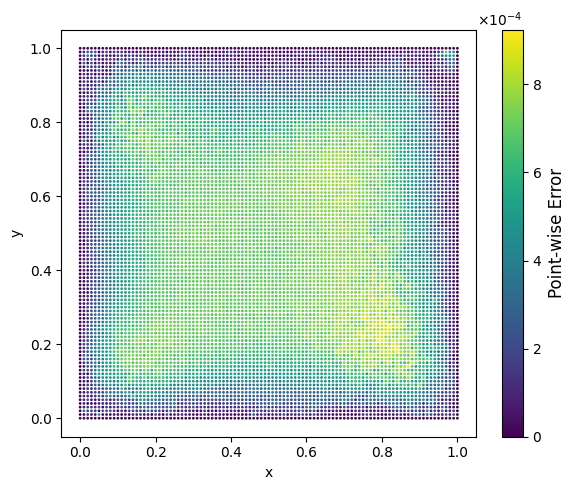

In [8]:

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 20
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y: x * np.cos(y)
# f_func = lambda x, y: 0 * np.cos(y) + x * np.cos(y)
# g_func = lambda x, y: x * np.cos(y)
# #===========================================================
# #==================== Evaluate points Y ====================
# #===========================================================
data = loadmat('./data/mydata_100_pdetool_square_10201.mat') # sigma2 = 0.1, l = 0.25

p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
Y = np.concatenate([Yin,Yb],axis=0)
f_func = f_new[index_in,testnum] 
g_func = u_new[index_bc,testnum]
order = 3
K = 100
reg = 1e-14

u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================

N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 400
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
print(f"X_inner.shape: {X_inner.shape[0]}, X_boundary.shape:{X_boundary.shape[0]}")
X = np.vstack([X_inner, X_boundary])

# print(f"X.shape, {X.shape}")
# # ===========================================================
newton_opt={"maxiter": 20, "tol": 1e-13, "damping": 1e-12, "linearstep": 1}

if order == 0:
    UY,LI,Lx,Ly,L = rfm_fd_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, newton_opt)
else:
    UY,LI,Lx,Ly,L = rfm_fd_poly_solve_nonlinear_poisson(X, Yin, Yb, f_func, g_func, Phi, K, reg, order, newton_opt)

print("p = ", order, "u_true.shape: ",u_true.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
print(error.max().item())
print(error[M1:,:].max().item())

print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=1)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_xcos_operator.eps', bbox_inches='tight')
plt.show()

## |Y| \noneq |X|, k = 150
## order = 0, reg = 1e-
## order = 1, reg = 1e-
## order = 2, reg = 1e-14 ? 1e-13 ? 1e-12 ? 1e-15 
## order = 3, reg = 1e-14 ? 1e-13 ? 1e-12 ? 1e-15(>:better)


In [9]:
import time
# only calculate 20
E_inf, E_L2 = np.zeros((20,1)),np.zeros((20,1))
f_vec = f_new[index_in,:]
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:20],u_true[index_bc,:20]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)


start_time = time.time()
UY = test_solver_batch(L, Lx, Ly, LI, f_vec, g_vec, newton_opt)
UY[M1:,:] = g_vec
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)


(10201, 20) (9801, 20) (400, 20)


Newton 0: max rel_res=3.242e+00, mean rel_res=1.328e+00
Newton 1: max rel_res=1.903e+00, mean rel_res=9.948e-01
Newton 2: max rel_res=9.375e-02, mean rel_res=4.184e-02
Newton 3: max rel_res=2.990e-02, mean rel_res=1.899e-02
Newton 4: max rel_res=2.463e-02, mean rel_res=1.660e-02
Newton 5: max rel_res=2.334e-02, mean rel_res=1.527e-02
Newton 6: max rel_res=2.040e-02, mean rel_res=1.380e-02
Newton 7: max rel_res=1.999e-02, mean rel_res=1.294e-02
Newton 8: max rel_res=1.817e-02, mean rel_res=1.201e-02
Newton 9: max rel_res=1.769e-02, mean rel_res=1.128e-02
Newton 10: max rel_res=1.658e-02, mean rel_res=1.069e-02
Newton 11: max rel_res=1.602e-02, mean rel_res=1.007e-02
Newton 12: max rel_res=1.534e-02, mean rel_res=9.683e-03
Newton 13: max rel_res=1.468e-02, mean rel_res=9.177e-03
Newton 14: max rel_res=1.429e-02, mean rel_res=8.907e-03
Newton 15: max rel_res=1.374e-02, mean rel_res=8.490e-03
Newton 16: max rel_res=1.354e-02, mean rel_res=8.307e-03
Newton 17: max rel_res=1.299e-02, mean re

q is  3


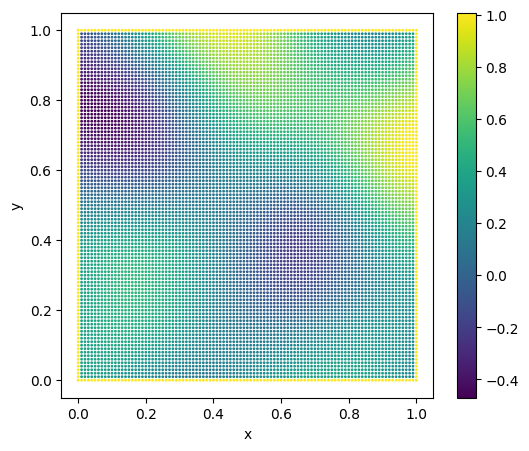

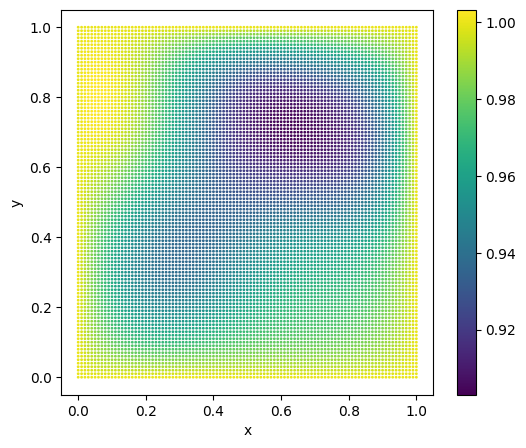

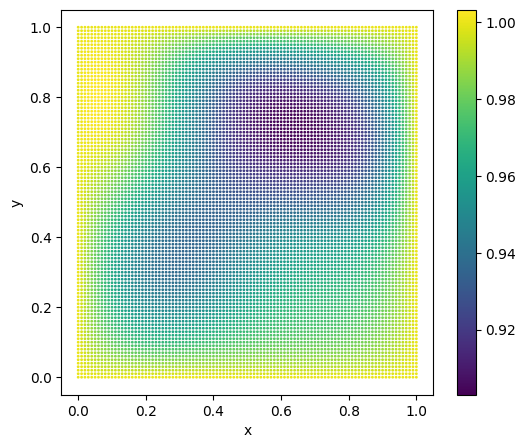

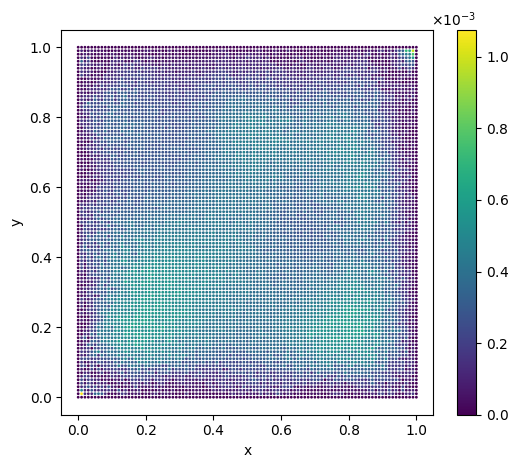

p = 3, test on 20 samples. The mean of max error: 1.776216e-03, and mean of relative L2 error: 5.602856e-04
p = 3, test on 20 samples. The variance of max error: 6.726969e-07, and variance of relative L2 error: 7.482706e-09


In [10]:
np.random.seed(20)
q = np.random.randint(0,20)
print("q is ", q)
f_test = np.concatenate([f_vec[:,q],g_vec[:,q]],axis = 0)
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = f_test, cmap='viridis', s=1)
plt.colorbar(sc)
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/nonlinear_poisson_square_rfmfd_p={order}_f_test_size{M}.eps', bbox_inches='tight')
plt.show()

import matplotlib.colors as mcolors
v_min = u_true[:, q].min()
v_max = u_true[:, q].max()
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=1, norm=norm)
plt.colorbar(sc)
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/nonlinear_poisson_square_rfmfd_p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=1, norm=norm)
plt.colorbar(sc)
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/nonlinear_poisson_square_rfmfd_p={order}_u_rfmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=1)
cbar = plt.colorbar(sc)
# cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/nonlinear_poisson_square_rfmfd_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 20 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 20 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")